# Data Preparation for ML

**Applied ML in Production · Session 2**

---

Session 1 ended with a charter and a warning: *some columns may not be available
at decision time*. This session is where we find out which one, and it is the
most important two hours of the module.

Data preparation is the work of turning a raw extract into a matrix a model can
learn from — handling missing values, encoding categories, scaling numbers, and
splitting into train and test. None of that is difficult. What is difficult is
doing it **without smuggling information from the future into the training set**,
and that mistake — *data leakage* — is the single most common reason a model
scores brilliantly in a notebook and fails in production.

Today we plant ourselves in front of a model that looks excellent, prove it is a
fraud, and fix it.

## How to work through this

Type the code yourself rather than only running it. Every cell here is short on
purpose — a few lines each, no clever tricks — because the point is the
reasoning, not the syntax.

Run each cell, read the output, then read the commentary. If a cell errors, run
from the top.

## Learning objectives

After this session you will be able to:

- Inspect a raw dataset for dtypes, duplicates, impossible values, and missingness
  before changing anything.
- **Detect data leakage** in a dataset you did not create, and explain the four
  kinds you will meet in industry.
- Distinguish missing-at-random from missing-not-at-random, and show what
  `dropna()` quietly costs.
- Impute missing values correctly — fitting on training data only.
- Encode categorical variables, and explain why a 40-category column is a problem.
- Scale and transform numeric features, and say which models care.
- Choose between a random split and a time-based split, and justify the choice.
- Order the whole preparation sequence so that no step sees data it should not.

## Setup

Same helper as session 1: walk up from the current folder until the repository's
`data/` directory appears, so the notebook does not care where the kernel started.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)


def find_data(filename="loan_default.csv"):
    for folder in [Path.cwd(), *Path.cwd().parents]:
        candidate = folder / "data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"could not find data/{filename}")


loans = pd.read_csv(find_data(), parse_dates=["application_date"])
print(loans.shape)
loans.head(3)

(12000, 15)


,loan_id,application_date,branch,sector,employment_type,loan_amount,tenure_months,interest_rate,annual_income,credit_score,has_collateral,previous_loans,days_past_due_history,recovery_agent_assigned,defaulted
0,NL200000,2023-01-01,Birgunj-01,Service,Business Owner,417000.0,36,10.28,194000.0,652.0,Yes,2,40,Yes,1
1,NL200001,2023-01-01,Biratnagar-03,Service,Self-Employed,154000.0,12,9.82,NaN,695.0,Yes,1,0,No,0
2,NL200002,2023-01-01,Kathmandu-03,Trade,Salaried,163000.0,24,13.04,948000.0,565.0,No,2,22,No,0


---

## 1. Look before you touch

Before cleaning anything, find out what you have. Four questions, four short
cells. Do this every single time you meet a dataset, including ones a colleague
swears are clean.

**Question 1: what type is each column, and how complete is it?**

In [2]:
summary = pd.DataFrame({
    "dtype": loans.dtypes.astype(str),
    "missing_%": (loans.isna().mean() * 100).round(1),
    "unique": loans.nunique(),
})
print(summary.to_string())

                                  dtype  missing_%  unique
loan_id                             str        0.0   12000
application_date         datetime64[us]        0.0     731
branch                              str        0.0      40
sector                              str        0.0       6
employment_type                     str        0.0       4
loan_amount                     float64        0.0    1362
tenure_months                     int64        0.0       7
interest_rate                   float64        0.0     778
annual_income                   float64        9.4    1613
credit_score                    float64        7.1     493
has_collateral                      str        0.0       2
previous_loans                    int64        0.0       9
days_past_due_history             int64        0.0      99
recovery_agent_assigned             str        0.0       2
defaulted                         int64        0.0       2


Two columns have gaps — `annual_income` (9.4%) and `credit_score` (7.1%) — and
`branch` has 40 distinct values, which will matter when we encode it.

**Question 2: are there duplicate rows?**

In [3]:
print("exact duplicate rows:", loans.duplicated().sum())
print("duplicate loan_id values:", loans["loan_id"].duplicated().sum())
print("duplicates ignoring the id column:", loans.drop(columns="loan_id").duplicated().sum())

exact duplicate rows: 0
duplicate loan_id values: 0
duplicates ignoring the id column: 0


Clean here. The third check matters more than the first: an id column is unique
by construction, so duplicated records often hide behind different ids. In
industry, the usual cause is a join that fanned out — one application matched to
three payment rows — and it inflates your test scores by putting near-copies of
training rows into the test set.

**Question 3: are the numbers possible?**

In [4]:
print(loans[["loan_amount", "annual_income", "credit_score",
             "interest_rate", "days_past_due_history"]].describe().round(0).to_string())

       loan_amount  annual_income  credit_score  interest_rate  days_past_due_history
count      12000.0        10878.0       11149.0        12000.0                12000.0
mean      388948.0       585418.0         639.0           12.0                   13.0
std       347994.0       403040.0          94.0            1.0                   13.0
min        50000.0        93000.0         300.0            9.0                    0.0
25%       178000.0       316000.0         574.0           11.0                    3.0
50%       292000.0       479000.0         638.0           12.0                    8.0
75%       486000.0       735000.0         704.0           13.0                   18.0
max     10000000.0      4604000.0         850.0           19.0                  121.0


Scan the `min` and `max` rows first. Negative incomes, ages of 200, credit scores
above 850, dates in the future — those are the errors you catch here in ten
seconds and otherwise chase for a week. This extract looks physically plausible.

**Question 4: what does each categorical column contain?**

In [5]:
for column in ["sector", "employment_type", "has_collateral", "recovery_agent_assigned"]:
    print(f"{column}: {loans[column].unique().tolist()}")

sector: ['Service', 'Trade', 'Tourism', 'Construction', 'Agriculture', 'Manufacturing']
employment_type: ['Business Owner', 'Self-Employed', 'Salaried', 'Informal']
has_collateral: ['Yes', 'No']
recovery_agent_assigned: ['Yes', 'No']


Look at that last column for a moment. `recovery_agent_assigned` — Yes or No.
Hold that thought.

---

## 2. The leakage hunt

We now build the model our charter asked for: every plausible feature, one
simple algorithm, honest split. Then we look at the score.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

NUMERIC = ["loan_amount", "tenure_months", "interest_rate", "previous_loans",
           "days_past_due_history", "annual_income", "credit_score"]
CATEGORICAL = ["sector", "employment_type", "has_collateral", "recovery_agent_assigned"]

X = pd.get_dummies(loans[NUMERIC + CATEGORICAL], drop_first=True).astype(float)
y = loans["defaulted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print(X.shape, "features after encoding")

(12000, 17) features after encoding


In [7]:
# Fill gaps with the TRAINING median, scale, fit. (Each step is explained below —
# right now we only care about the score.)
medians = X_train.median()
X_train, X_test = X_train.fillna(medians), X_test.fillna(medians)

scaler = StandardScaler().fit(X_train)
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(scaler.transform(X_train), y_train)

probabilities = model.predict_proba(scaler.transform(X_test))[:, 1]
predictions = model.predict(scaler.transform(X_test))

print(f"ROC-AUC:   {roc_auc_score(y_test, probabilities):.3f}")
print(f"recall:    {recall_score(y_test, predictions):.3f}")
print(f"precision: {precision_score(y_test, predictions):.3f}")

ROC-AUC:   0.974
recall:    0.891
precision: 0.828


An AUC of 0.97 and precision of 0.83 on credit default, from plain logistic
regression, on the first attempt.

If you are pleased, you have just made the mistake. **Credit risk is hard.**
Lenders with decades of data, dedicated teams, and bureau feeds do not get
numbers like this. When a result is far better than the problem allows, the
model has usually found something it will not have on the day.

### Find the culprit

The fastest diagnostic is also the simplest: for each categorical column, look at
the default rate inside each of its values. A column that splits the target
almost perfectly is either a miracle or a leak.

In [8]:
for column in CATEGORICAL:
    print(loans.groupby(column)["defaulted"].mean().round(3).to_string(), "\n")

sector
Agriculture      0.122
Construction     0.168
Manufacturing    0.123
Service          0.133
Tourism          0.152
Trade            0.135 

employment_type
Business Owner    0.126
Informal          0.173
Salaried          0.129
Self-Employed     0.131 

has_collateral
No     0.180
Yes    0.102 

recovery_agent_assigned
No     0.018
Yes    0.831 



There it is.

Where `recovery_agent_assigned` is `"Yes"`, 83% of loans defaulted. Where it is
`"No"`, 1.8% did. No genuine applicant characteristic behaves like that — not
credit score, not sector, not employment type, which all move the rate by a few
points at most.

Now apply the **point-in-time rule** from session 1: *would this value exist, for
this applicant, at the moment the decision is made?*

A recovery agent is assigned to chase an account **after it has gone bad**. At
application time, the moment our model runs, that field is empty for everyone.
The column is not a predictor of default; it is a *record* of default, wearing a
different name.

This is **target leakage**, and it is in the file for the most ordinary reason
imaginable: the extract was built by joining whatever the warehouse holds today,
and today it holds the collections table.

In [9]:
# Same model, same everything, minus the leaking column.
CATEGORICAL_CLEAN = ["sector", "employment_type", "has_collateral"]

X = pd.get_dummies(loans[NUMERIC + CATEGORICAL_CLEAN], drop_first=True).astype(float)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

medians = X_train.median()
X_train, X_test = X_train.fillna(medians), X_test.fillna(medians)

scaler = StandardScaler().fit(X_train)
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(scaler.transform(X_train), y_train)

probabilities = model.predict_proba(scaler.transform(X_test))[:, 1]
predictions = model.predict(scaler.transform(X_test))

print(f"ROC-AUC:   {roc_auc_score(y_test, probabilities):.3f}   (was 0.974)")
print(f"recall:    {recall_score(y_test, predictions):.3f}   (was 0.891)")
print(f"precision: {precision_score(y_test, predictions):.3f}   (was 0.828)")

ROC-AUC:   0.783   (was 0.974)
recall:    0.696   (was 0.891)
precision: 0.273   (was 0.828)


AUC falls from 0.974 to 0.783. Precision collapses from 0.83 to 0.27.

**That is the good news.** 0.783 is a real number that will survive contact with
production. 0.974 was a number that would have been reported to the Head of
Credit, believed, deployed, and then quietly produced garbage — because in
production `recovery_agent_assigned` is `"No"` for every applicant, and the model
leans on it hardest.

The cost of finding this in session 2 is one afternoon. The cost of finding it
after launch is the project.

> **Industry note — the drop that saves you.**
> A sudden drop in performance after removing a column is the healthiest thing
> that can happen to a project. Teams that never see one are usually not looking.
> Practising data scientists develop an instinct: when a score is surprisingly
> high, the first hypothesis is leakage, not brilliance.

### The four kinds of leakage

| Kind | What happens | How to catch it |
|------|--------------|-----------------|
| **Target leakage** | A feature is recorded after, or because of, the outcome — our `recovery_agent_assigned` | Point-in-time rule; look for suspiciously strong single features |
| **Train-test contamination** | A preparation step looks at the test set — a median, a scaler, an encoding fitted on all the data | Fit every transformation on train only; use a `Pipeline` (session 7) |
| **Temporal leakage** | A random split trains on the future and tests on the past | Split by time whenever predictions are made forward in time |
| **Group leakage** | Rows from the same entity land in both train and test — three loans from one borrower | Split by group id, not by row |

### The leakage checklist

Run this on every project, before modelling:

1. For every column, ask when the value is written. Not what it means — *when*.
2. Sort features by single-feature predictive power. Investigate the top of that list.
3. If the score is far better than the problem's known difficulty, assume leakage.
4. Fit every imputer, scaler and encoder on training data only.
5. If time matters, split on time. If entities repeat, split on entity.

### Contamination, in practice

Leakage rule 4 says: fit on train only. Here is what that means concretely.

In [10]:
credit = loans["credit_score"]
train_part, test_part = train_test_split(credit, test_size=0.25, random_state=42)

print(f"median over the whole dataset: {credit.median():.1f}   <- wrong, sees the test set")
print(f"median over training rows only: {train_part.median():.1f}   <- correct")

median over the whole dataset: 638.0   <- wrong, sees the test set
median over training rows only: 638.0   <- correct


Identical, to the decimal point. So does it matter?

Yes, and the reason is worth understanding. With 12,000 rows and a well-behaved
column, using the whole dataset's median changes almost nothing — you got lucky.
The same shortcut is severe when:

- the dataset is small (a few hundred rows, where a handful of test values move
  the median),
- the statistic is sensitive to outliers (a mean, a max, a standard deviation),
- the transformation involves the **target** — encoding a category by its average
  default rate is a leak the moment it is fitted on all rows (session 3),
- you resample or oversample before splitting, which copies the same row into
  both sides.

The rule costs you nothing to follow and occasionally saves the project. Follow
it even when it looks pointless, because you cannot tell in advance which case
you are in.

---

## 3. Missing values

Two columns have gaps. The instinct is to fill them or drop them and move on.
The correct first step is to ask **why they are missing**, because the answer
determines what you are allowed to do.

| Mechanism | Plain meaning | Example |
|-----------|---------------|---------|
| **MCAR** — missing completely at random | Gaps unrelated to anything | A form was lost in transit |
| **MAR** — missing at random | Gaps explained by *other columns you have* | Income undocumented for informal workers |
| **MNAR** — missing not at random | Gaps explained by the missing value itself | High earners decline to state income |

MCAR is safe to impute and rare. MAR is the common case and the interesting one:
the missingness itself carries information. MNAR is dangerous and often needs a
conversation with the business rather than a statistical fix.

Which do we have? Look.

In [11]:
income_missing = loans["annual_income"].isna()

print("share with no recorded income, by employment type")
print(income_missing.groupby(loans["employment_type"]).mean().round(3).to_string())

first_time = loans["previous_loans"] == 0
print("\nshare with no credit score")
print("  first-time borrowers:", round(loans.loc[first_time, "credit_score"].isna().mean(), 3))
print("  borrowed before:     ", round(loans.loc[~first_time, "credit_score"].isna().mean(), 3))

share with no recorded income, by employment type
employment_type
Business Owner    0.015
Informal          0.336
Salaried          0.021
Self-Employed     0.115

share with no credit score
  first-time borrowers: 0.218
  borrowed before:      0.015


Not random at all.

Informal workers are missing income roughly 17 times as often as salaried
applicants — because they have no payslip to document. First-time borrowers are
missing a credit score about 15 times as often as repeat borrowers — because a
score is built from a borrowing history they do not have.

This is textbook MAR, and it has a consequence people miss: **the fact that a
value is missing is itself a feature.** "No documented income" tells you
something real about an applicant.

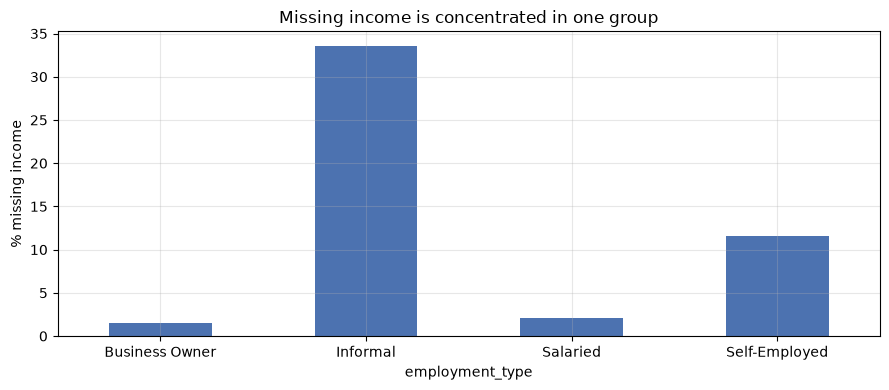

In [12]:
fig, ax = plt.subplots()
(income_missing.groupby(loans["employment_type"]).mean() * 100).plot.bar(
    ax=ax, color="#4C72B0", rot=0)
ax.set_ylabel("% missing income")
ax.set_title("Missing income is concentrated in one group")
plt.tight_layout()
plt.show()

### What `dropna()` costs

The one-line fix deletes rows. Count what leaves with them.

In [13]:
complete = loans.dropna()

print(f"rows kept:           {len(complete):,} of {len(loans):,} "
      f"({1 - len(complete) / len(loans):.1%} deleted)")
print(f"default rate:        {complete['defaulted'].mean():.1%}  (full data {loans['defaulted'].mean():.1%})")
print(f"informal applicants: {(complete['employment_type'] == 'Informal').mean():.1%}  "
      f"(full data {(loans['employment_type'] == 'Informal').mean():.1%})")

rows kept:           10,118 of 12,000 (15.7% deleted)
default rate:        13.2%  (full data 13.5%)
informal applicants: 10.9%  (full data 14.8%)


`dropna()` deleted 15.7% of the book and, with it, 38% of the informal
applicants — 678 of 1,778. The surviving sample is *better documented and lower risk than
reality* — so the model learns a population it will not meet, and it will meet
informal applicants at the counter tomorrow morning.

This is what makes missing-data handling an ethical question as well as a
technical one. The rows that vanish are rarely random people.

### Imputation, done correctly

| Strategy | When | Watch out |
|----------|------|-----------|
| Drop rows | Gaps are tiny (<1%) and MCAR | Silently changes who your model represents |
| Drop the column | Mostly empty, or the gap is unfixable | You may be dropping a strong signal |
| **Median / mode fill** | The default for MAR numeric and categorical data | Shrinks variance; always pair with a flag |
| **Missing indicator flag** | Whenever missingness is informative | One extra column per imputed feature |
| Model-based (KNN, iterative) | Small data, rich correlations | Slow, easy to leak, hard to explain |

Median rather than mean, because money columns are skewed and one 40-million
income drags a mean upward. And the flag, because "we had to guess this" is
information the model should be allowed to use.

In [14]:
features = loans[NUMERIC + CATEGORICAL_CLEAN].copy()

# The flag must be created BEFORE filling, or there is nothing left to record.
features["income_missing"] = features["annual_income"].isna().astype(int)
features["score_missing"] = features["credit_score"].isna().astype(int)

X = pd.get_dummies(features, drop_first=True).astype(float)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

medians = X_train.median()          # fitted on train
X_train = X_train.fillna(medians)   # applied to train
X_test = X_test.fillna(medians)     # and to test, using the TRAIN values

print("missing values left:", int(X_train.isna().sum().sum()), int(X_test.isna().sum().sum()))
print("median income used for filling: NPR", f"{medians['annual_income']:,.0f}")

missing values left: 0 0
median income used for filling: NPR 480,000


Three lines, in an order that matters: flag, split, then fill with training
medians. Reverse any two of those and you have leaked.

> **Industry note — the flag that paid for itself.**
> On this dataset the missing-indicator flags barely move the score, and we keep
> them anyway. On datasets where missingness is driven by the process — a field
> only filled in when a case is escalated, a reading only taken when a machine
> alarms — those flags are regularly among the strongest features in the model.
> They cost two lines. Add them, then check whether they earned their place.

---

## 4. Categorical variables

Models take numbers. `sector` is a word. Something has to give.

**Ordinal** categories have a real order — small/medium/large, or a risk grade of
A/B/C. Map them to integers that respect that order.

**Nominal** categories do not — `sector`, `branch`, `employment_type`. Mapping
Trade to 1 and Tourism to 6 invents an ordering that does not exist and a model
will believe it. Use **one-hot encoding**: one 0/1 column per value.

In [15]:
encoded = pd.get_dummies(loans[["sector", "employment_type", "has_collateral"]],
                         drop_first=True).astype(int)
print(f"3 categorical columns became {encoded.shape[1]} numeric columns")
encoded.head(3)

3 categorical columns became 9 numeric columns


,sector_Construction,sector_Manufacturing,sector_Service,sector_Tourism,sector_Trade,employment_type_Informal,employment_type_Salaried,employment_type_Self-Employed,has_collateral_Yes
0,0,0,1,0,0,0,0,0,1
1,0,0,1,0,0,0,0,1,1
2,0,0,0,0,1,0,1,0,0


`drop_first=True` removes one column per category — with `has_collateral_Yes`
present, a `has_collateral_No` column adds nothing. It matters for linear models
(perfectly correlated columns make coefficients unstable) and is harmless
elsewhere.

### The 40-branch problem

In [16]:
print("distinct branches:", loans["branch"].nunique())
print("one-hot columns if we encode it:", pd.get_dummies(loans["branch"]).shape[1])
print("\nsmallest branches by volume:")
print(loans["branch"].value_counts().tail(3).to_string())

distinct branches: 40
one-hot columns if we encode it: 40

smallest branches by volume:
branch
Kathmandu-04     272
Biratnagar-04    271
Nepalgunj-03     270


High-cardinality categoricals are a genuine trap. Forty extra columns, most of
them nearly empty, each giving the model a chance to memorise a handful of rows —
and a new branch opening next year produces a category the encoder has never seen.

Options, in the order you should consider them:

1. **Leave it out** and check whether the model actually suffers. Often it does not.
2. **Group it** — keep the top 10 branches, collapse the rest into `"Other"`.
3. **Replace it with something meaningful** — city, province, branch size,
   branch age. Usually what you wanted from `branch` anyway.
4. **Target encoding** — replace each branch with its historical default rate.
   Powerful, and a leak in waiting unless fitted inside a cross-validation fold.
   Session 3.

We leave `branch` out for now and revisit it when we do feature engineering.

> **Production note.** `pd.get_dummies` is perfect for exploring and wrong for
> serving: it produces whatever columns the data happens to contain, so a new
> category or a missing one silently changes the shape of your matrix. In a
> deployed system use `OneHotEncoder(handle_unknown="ignore")` inside a
> pipeline, which remembers the training categories. That is session 7.

---

## 5. Scaling and transforming numbers

`loan_amount` runs from 50,000 to 10,000,000. `tenure_months` runs from 6 to 60.
To a model that measures distances or follows gradients, the first column shouts
and the second whispers — not because it matters more, but because its units are
bigger.

**Models that need scaling:** logistic regression, SVM, KNN, K-means, neural
networks, anything regularised.
**Models that do not care:** decision trees, random forests, gradient boosting.
They split on order, and order survives any monotonic rescaling.

In [17]:
print(loans[["loan_amount", "tenure_months", "annual_income"]].describe().loc[["mean", "std", "max"]].round(0).to_string())

      loan_amount  tenure_months  annual_income
mean     388948.0           26.0       585418.0
std      347994.0           14.0       403040.0
max    10000000.0           60.0      4604000.0


Before scaling, deal with **skew**. Money is almost never symmetric.

skew of loan_amount:       5.19
skew of log(loan_amount):  0.05


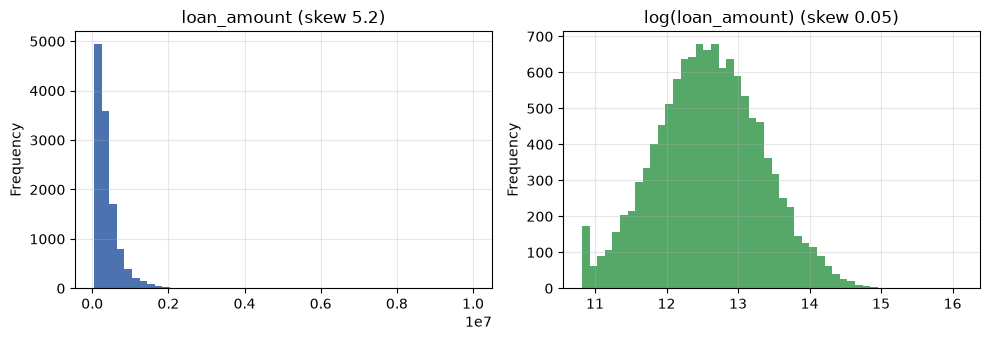

In [18]:
print("skew of loan_amount:      ", round(loans["loan_amount"].skew(), 2))
print("skew of log(loan_amount): ", round(np.log(loans["loan_amount"]).skew(), 2))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
loans["loan_amount"].plot.hist(bins=50, ax=axes[0], color="#4C72B0")
axes[0].set_title("loan_amount (skew 5.2)")
np.log(loans["loan_amount"]).plot.hist(bins=50, ax=axes[1], color="#55A868")
axes[1].set_title("log(loan_amount) (skew 0.05)")
plt.tight_layout()
plt.show()

A long right tail becomes a tidy bell. Use `np.log1p` rather than `np.log` in
practice — it handles zeros, which `log` does not.

The transform is not compulsory. It helps linear models, which assume a roughly
even spread of errors, and does nothing for trees. It also changes what a
coefficient means: after a log transform, a coefficient describes *percentage*
change, not rupees.

### Standardisation

In [19]:
scaler = StandardScaler().fit(X_train)          # learns mean and std from TRAIN
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)        # uses the TRAIN mean and std

print("train mean (should be ~0):", X_train_scaled.mean().round(3))
print("train std  (should be ~1):", X_train_scaled.std().round(3))
print("test mean  (NOT exactly 0, and that is correct):", X_test_scaled.mean().round(3))

train mean (should be ~0): -0.0
train std  (should be ~1): 1.0
test mean  (NOT exactly 0, and that is correct): 0.001


The test mean is not zero, and it must not be. The scaler was fitted on the
training data; the test set is being treated exactly as a live application will
be — measured against statistics computed before it arrived.

If your test set scales to a perfect mean of 0, you fitted the scaler on
everything, and you have leaked.

| Transform | Use when |
|-----------|----------|
| `StandardScaler` | Default. Roughly bell-shaped features |
| `MinMaxScaler` | You need a bounded [0, 1] range |
| `RobustScaler` | Heavy outliers — uses median and quartiles |
| `log1p` | Right-skewed money or count columns, applied before scaling |

---

## 6. Splitting: the decision that outranks the rest

A split is a claim: *"the test set stands in for the data this model will see
after launch."* Make the claim badly and every number downstream is decoration.

**Random split** — `train_test_split`, optionally stratified so both sides carry
the same share of defaults. Appropriate when rows are independent and time is
irrelevant.

**Time-based split** — train on the past, test on the future. Appropriate
whenever predictions are made forward in time, which includes every loan, every
churn model, and every demand forecast.

Our model will be applied to applications that have not been submitted yet. So:

In [20]:
cutoff = pd.Timestamp("2024-07-01")

train_rows = loans[loans["application_date"] < cutoff]
test_rows = loans[loans["application_date"] >= cutoff]

print(f"train: {len(train_rows):,} applications before {cutoff:%d %b %Y}, "
      f"default rate {train_rows['defaulted'].mean():.1%}")
print(f"test:  {len(test_rows):,} applications after,  "
      f"default rate {test_rows['defaulted'].mean():.1%}")

train: 9,029 applications before 01 Jul 2024, default rate 11.9%
test:  2,971 applications after,  default rate 18.5%


Stop and look at those two numbers. The training period defaults at 11.9%; the
test period at 18.5%. Under the random split we used earlier, both sides sat at
13.5%, because randomising shuffled the two periods together.

The random split was hiding something real: **the later period behaves
differently from the earlier one.** A model tuned on the earlier period will be
optimistic about the later one, and a random split would never have told you.

Note the observation, do not chase it — session 8 is devoted to what causes this
and how to detect it in production. For now, take the lesson: *how you split
determines what you are able to notice.*

In [21]:
# Always check the boundary actually holds.
print(f"latest in train:  {train_rows['application_date'].max():%d %b %Y}")
print(f"earliest in test: {test_rows['application_date'].min():%d %b %Y}")
print("no overlap:",
      train_rows["application_date"].max() < test_rows["application_date"].min())

latest in train:  30 Jun 2024
earliest in test: 01 Jul 2024
no overlap: True


Cut on a **date**, not on a row count. `iloc[:9000]` can land in the middle of a
day and put applications from the same morning on both sides of the split — a
small leak, and an annoying one to find later.

| Split | Use when | Gotcha |
|-------|----------|--------|
| Random | Rows independent, time irrelevant | Hides time effects completely |
| Stratified random | Imbalanced target, time irrelevant | Same |
| **Time-based** | Predicting forward in time | Test set may be small; recent data is precious |
| Group-based | Repeated entities (borrowers, patients, devices) | Needs a reliable group id |

A validation set is a third slice, carved out of training data, used for tuning
so the test set stays untouched until the end. Session 6 sets that up properly
with cross-validation.

---

## 7. The order of operations

Every step so far has one rule attached: *learn it from training data, apply it
everywhere*. The order that respects this:

1. **Split first.** Before imputing, encoding, scaling or resampling.
2. **Create missingness flags** — from raw values, before filling.
3. **Fit the imputer on train**, apply to train and test.
4. **Fit the encoder on train**, apply to both; unseen categories become zeros.
5. **Fit the scaler on train**, apply to both.
6. **Resample for imbalance on train only** (session 3) — never touch the test set.
7. Train. Evaluate once, at the end.

Doing this by hand is error-prone, which is exactly why `Pipeline` exists. We
build it in session 7; until then, follow the order deliberately.

In [22]:
def prepare_and_score(feature_columns, add_flags=False, drop_missing=False):
    """Prepare, train, and report — so we can compare choices fairly."""
    data = loans.dropna() if drop_missing else loans
    features = data[feature_columns].copy()

    if add_flags:
        features["income_missing"] = features["annual_income"].isna().astype(int)
        features["score_missing"] = features["credit_score"].isna().astype(int)

    X = pd.get_dummies(features, drop_first=True).astype(float)
    X_train, X_test, y_train, y_test = train_test_split(
        X, data["defaulted"], test_size=0.25, stratify=data["defaulted"], random_state=42
    )

    medians = X_train.median()
    X_train, X_test = X_train.fillna(medians), X_test.fillna(medians)

    scaler = StandardScaler().fit(X_train)
    model = LogisticRegression(max_iter=1000, class_weight="balanced")
    model.fit(scaler.transform(X_train), y_train)

    probabilities = model.predict_proba(scaler.transform(X_test))[:, 1]
    predictions = model.predict(scaler.transform(X_test))
    return {
        "roc_auc": roc_auc_score(y_test, probabilities),
        "recall": recall_score(y_test, predictions),
        "precision": precision_score(y_test, predictions),
    }


comparison = pd.DataFrame({
    "with the leak": prepare_and_score(NUMERIC + CATEGORICAL),
    "leak removed": prepare_and_score(NUMERIC + CATEGORICAL_CLEAN),
    "leak removed + flags": prepare_and_score(NUMERIC + CATEGORICAL_CLEAN, add_flags=True),
    "leak removed + dropna()": prepare_and_score(NUMERIC + CATEGORICAL_CLEAN, drop_missing=True),
}).T.round(3)

print(comparison.to_string())

                         roc_auc  recall  precision
with the leak              0.974   0.891      0.828
leak removed               0.783   0.696      0.273
leak removed + flags       0.782   0.694      0.275
leak removed + dropna()    0.748   0.680      0.254


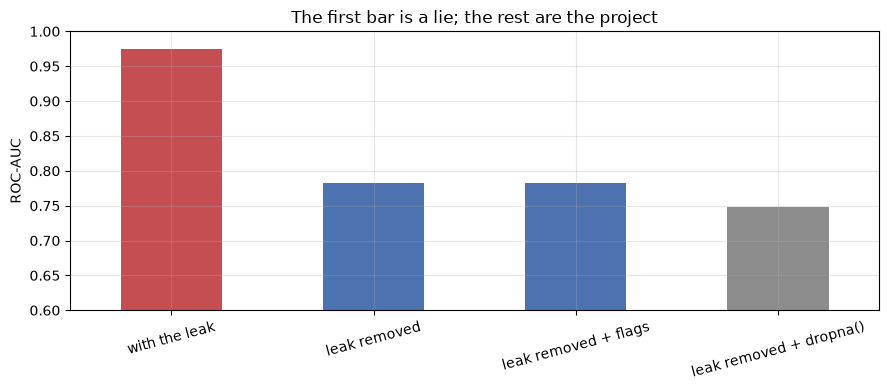

In [23]:
fig, ax = plt.subplots()
comparison["roc_auc"].plot.bar(ax=ax, color=["#C44E52", "#4C72B0", "#4C72B0", "#8C8C8C"], rot=15)
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.6, 1.0)
ax.set_title("The first bar is a lie; the rest are the project")
plt.tight_layout()
plt.show()

Read the table honestly.

**The leak is worth 0.19 AUC of pure fantasy.** It is the tallest bar and the
only worthless one.

**The missingness flags changed almost nothing here** (0.783 to 0.782). We keep
them because they cost two lines and because on the next dataset they will
matter — but notice that we *checked* rather than assumed. A technique that
should help and does not is a finding, not an embarrassment.

**Imputing beat dropping** (0.783 against 0.748). Keeping 1,882 imperfect rows
was better than deleting them, and it also kept the informal applicants in the
training population where they belong.

The honest model is now the starting point for session 3, where we stop cleaning
features and start building them.

---

## Your turn

**1. Finish the availability audit.** Session 1 asked you to sort all 15 columns
into *known at application time* / *known later* / *not sure*. Do it now with the
leak in hand. Is `days_past_due_history` safe? What exactly would you ask the
credit team to confirm it?

**2. Break it deliberately.** In `prepare_and_score`, compute `medians` from the
full `X` instead of `X_train`, and fit the scaler on the full `X` too. Report the
change in AUC. Explain why it is so small here and construct a situation where it
would not be.

**3. The dropna audit.** Beyond `employment_type`, find two more ways the
`dropna()` sample differs from the full dataset (try `previous_loans`, `sector`,
`credit_score`). Write one sentence on who is being excluded from the model.

**4. Group the branches.** Keep the 10 largest branches, collapse the rest into
`"Other"`, one-hot encode the result, and re-run `prepare_and_score`. Did 40
categories buy anything? Does the grouped version?

**5. Split by time.** Change `prepare_and_score` to use the time-based split
instead of `train_test_split`. Compare the AUC to the random-split version and
explain the gap in one sentence. Which number would you put in front of the Head
of Credit?

**6. Plant your own leak.** Add a column `late_payment_flag` that is `"Yes"` for
90% of defaulters and 5% of everyone else. Re-run the model, then re-run the
diagnostic from section 2 and confirm it catches your leak.

---

## If you remember nothing else

**A score that is too good is a bug report.** Credit default does not yield
AUC 0.97 to a first-attempt logistic regression. Suspicion is a skill.

**Leakage is a timing question, not a statistics question.** For every column,
ask when the value is written, not what it means.

**Split before you do anything else.** Every imputer, encoder and scaler is
fitted on the training data and applied to the test data. No exceptions, even
when it looks harmless.

**Missing is information.** Find out why the gaps are there, flag them, and check
who disappears when you call `dropna()` — it is rarely a random sample of people.

**How you split decides what you can see.** A random split on time-ordered data
hid a real shift in this dataset completely.

---

## Glossary

| Term | Meaning |
|------|---------|
| **Data leakage** | Information in training that will not be available at prediction time |
| **Target leakage** | A feature recorded after or because of the outcome |
| **Train-test contamination** | A preparation step fitted on data that includes the test set |
| **Temporal leakage** | Training on data from after the test period |
| **Group leakage** | The same entity appearing in both train and test |
| **MCAR / MAR / MNAR** | Missing completely at random / at random given other columns / not at random |
| **Imputation** | Filling missing values with an estimate |
| **Missing indicator** | A 0/1 column recording that a value was imputed |
| **One-hot encoding** | One binary column per category value |
| **High cardinality** | A categorical column with many distinct values (our 40 branches) |
| **Standardisation** | Rescaling to mean 0, standard deviation 1 |
| **Stratified split** | A split preserving the class balance on both sides |

## Further reading

- scikit-learn User Guide, *Preprocessing data* and *Common pitfalls — data
  leakage* — the second is short, official, and should be required reading.
- Kaufman, Rosset and Perlich, *Leakage in Data Mining* (KDD 2011) — the paper
  that named the problem, full of real competition-winning leaks.
- Chip Huyen, *Designing Machine Learning Systems*, chapter 4 — training data,
  sampling, and labelling in production settings.
- Gelman and Hill on missing data mechanisms, for the statistics behind
  MCAR/MAR/MNAR.

---

**Next session:** *Feature Engineering* — building features that are not in the
file, selecting the ones that earn their place, and handling the 13.5% class
imbalance we have been quietly ignoring.